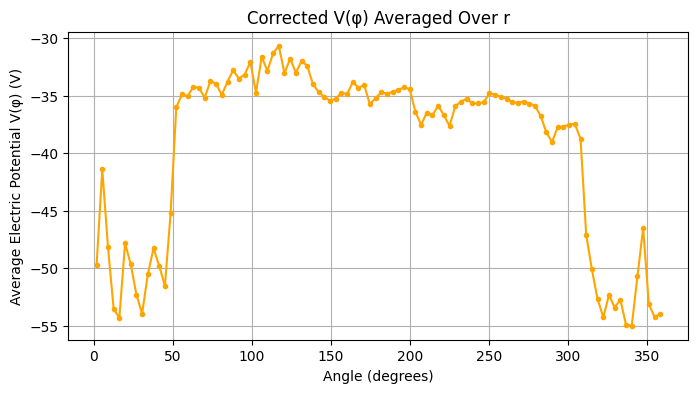

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "image.jpeg"  # Change this to your image file path
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale for contour detection
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
_, thresh = cv2.threshold(gray_image, 30, 255, cv2.THRESH_BINARY)

# Find the largest contour (assumed to be the circular data region)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
circle_contour = max(contours, key=cv2.contourArea)
(x_center, y_center), radius = cv2.minEnclosingCircle(circle_contour)
x_center, y_center, radius = int(x_center), int(y_center), int(radius)

# Create a mask for the circular region
mask = np.zeros_like(gray_image)
cv2.circle(mask, (x_center, y_center), radius, 255, -1)

# Extract pixel indices inside the circle
y_indices, x_indices = np.where(mask == 255)

# Convert pixel coordinates to polar
r_values = np.sqrt((x_indices - x_center) ** 2 + (y_indices - y_center) ** 2)
theta_values = np.arctan2(y_indices - y_center, x_indices - x_center)
theta_values = (theta_values + 2 * np.pi) % (2 * np.pi)  # Normalize theta to [0, 2π]

# Extract the colorbar on the right
height, width, _ = image_rgb.shape
colorbar_region = image_rgb[
    :, int(0.85 * width) :
]  # Rightmost 15% assumed to be colorbar
colorbar_rgb = colorbar_region[:, colorbar_region.shape[1] // 2, :]

# Define known values from the colorbar
color_values = np.linspace(-80, 0, len(colorbar_rgb))  # Potential from -80V to 0V


# Function to match pixel color to potential using RGB distance
def match_color_to_potential(pixel_rgb, colorbar_rgb, color_values):
    distances = np.linalg.norm(colorbar_rgb - pixel_rgb, axis=1)
    return color_values[np.argmin(distances)]


# Convert extracted circular region to potentials using RGB matching
extracted_rgb = image_rgb[y_indices, x_indices]
potential_values = np.array(
    [match_color_to_potential(rgb, colorbar_rgb, color_values) for rgb in extracted_rgb]
)

# Bin and average V(phi) over r
num_bins = 100
theta_bins = np.linspace(0, 2 * np.pi, num_bins + 1)
V_phi = np.zeros(num_bins)

for i in range(num_bins):
    mask = (theta_values >= theta_bins[i]) & (theta_values < theta_bins[i + 1])
    if np.any(mask):
        V_phi[i] = np.mean(potential_values[mask])
    else:
        V_phi[i] = np.nan  # Handle empty bins

# Convert theta bins to degrees for plotting
theta_bins_deg = np.degrees((theta_bins[:-1] + theta_bins[1:]) / 2)

# Plot V(phi)
plt.figure(figsize=(8, 4))
plt.plot(theta_bins_deg, V_phi, marker="o", linestyle="-", markersize=3, color="orange")
plt.xlabel("Angle (degrees)")
plt.ylabel("Average Electric Potential V(φ) (V)")
plt.title("Corrected V(φ) Averaged Over r")
plt.grid()
plt.show()